# Joint MCMC Analysis — DIB 15272 / 15672, C2v / Cs
Loads any backend produced by `run_emcee_asym_both.py`, infers all settings
from the filename, redoes the full convergence analysis, makes the corner plot,
and draws 10 posterior-sample profile overlays.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.gridspec as gridspec
import corner, h5py, os, glob, re, io, subprocess, tempfile
import emcee
from scipy.stats import gaussian_kde, ks_2samp
from scipy.ndimage import gaussian_filter
from scipy.interpolate import interp1d
from scipy.signal import fftconvolve
from IPython.display import display, Image
import warnings
import os.path as osp
warnings.filterwarnings('ignore')
from IPython.display import display, HTML
display(HTML("<style>.container { width:90% !important; }</style>"))

import sys
sys.path.insert(0, os.path.expanduser('~/DIB'))
from MCMC_convergence_tests import detect_multimodal, ks_stability_test, compute_rhat, format_diagnostics

# ── Matplotlib style ──────────────────────────────────────────────────────────
mpl.rcParams.update(mpl.rcParamsDefault)
plt.rcParams['figure.facecolor'] = 'white'
plt.rc('text', usetex=False)
plt.rc('font', family='serif', size=12)
plt.rc('axes', linewidth=1.5)
plt.rc('xtick', labelsize=11, direction='in', top=True)
plt.rc('ytick', labelsize=11, direction='in', right=True)
plt.rc('xtick.minor', visible=True)
plt.rc('ytick.minor', visible=True)
plt.rc('xtick.major', size=6, pad=4)
plt.rc('xtick.minor', size=3)
plt.rc('ytick.major', size=6)
plt.rc('ytick.minor', size=3)
plt.rc('legend', fontsize=10)
import datetime
import pandas as pd
from scipy.stats import chi2 as chi2_dist


In [2]:
backend_dir =  osp.expanduser("~/../../scratch/gpfs/MELCHIOR/cj1223/DIB") 
files = [f for f in os.listdir(backend_dir) if 'SymmetryC2v' in f and '_sweep_Andrew' in f and '.h5' in f]
files = [f for f in files if '15672' not in f]
files

['15272_run_DIB15272_SymmetryC2v_BCFalse_F1p0_DTrue_FlatFalse_SpecTrue_dTFalse_covFalse_nonlinFalse_tauSlope0p05_alphaSlope0p05_errDefault_trunc0_balanceErrFalse_dTcenterNone_centeroffset0p01_sweep_Andrew.h5']

## 1  User Configuration

In [13]:
# ════════════════════════════════════════════════════════════════════════════
#  FILE SELECTION
#   Set file_override = '/full/path/to/backend.h5' to pin a specific file.
#   Otherwise the script lists all matching files and picks file_index.
# ════════════════════════════════════════════════════════════════════════════
dib_band       = '15672'   # '15272' or '15672'
symmetry_group = 'Cs'    # 'C2v'  or 'Cs'
file_index     = 2   # which matching file to load (0 = most recently modified)
file_override  = None      # str path or None
# file_override = backend_dir + '/' + '15672_run_DIB15672_SymmetryC2v_BCTrue_F1p0_DTrue_FlatFalse_SpecTrue_dTTrue_covFalse_nonlinFalse_tauSlope0p15_alphaSlope0p15_errPlate_trunc10_balanceErrTrue_dTcenterNone_centeroffset0p15_test.h5'
# file_override = backend_dir + '/' + '15272_run_DIB15272_SymmetryCs_BCTrue_F1p0_DTrue_FlatFalse_SpecTrue_dTTrue_covFalse_nonlinFalse_tauSlope0p15_alphaSlope0p05_errDefault_trunc10_balanceErrFalse_dTcenter[10p0,3p0,2p0]_centeroffset0p01_sweep.h5'
# file_override = backend_dir + '/' + 'bc_run_SymmetryC2v_BCTrue_F1p0_DTrue_FlatFalse_SpecTrue_dTTrue_covFalse_nonlinFalse_tauSlope0p05_update.h5'
# file_override = backend_dir + '/' + '15672_run_DIB15672_SymmetryCs_BCTrue_F1p0_DTrue_FlatFalse_SpecTrue_dTTrue_covFalse_nonlinFalse_tauSlope0p15_alphaSlope0p15_errDefault_trunc0_balanceErrFalse_dTcenter[10p0,3p0,-2p0]_centeroffset0p1_sweep.h5'



file_override = backend_dir + '/' + '15272_run_DIB15272_SymCs_BCTrue_F1p0_DTrue_FlatFalse_SpecTrue_dTTrue_covFalse_nonlinFalse_tauSlope0p15_alphaSlope0p025_alphaCutFalse_errDefault_trunc10_balanceErrFalse_dTcent[10p0,2p0,2p0]_wavoffset0p01_dPTrue_restart_sym_alpha_deltaP.h5'

# file_override = backend_dir + '/' + '15672_run_DIB15672_SymCs_BCTrue_F1p0_DTrue_FlatFalse_SpecTrue_dTTrue_covFalse_nonlinFalse_tauSlope0p15_alphaSlope0p075_alphaCutFalse_errDefault_trunc10_balanceErrFalse_dTcent[10p0,2p0,-2p0]_wavoffset0p1_dPTrue_restart_sym_alpha_deltaP.h5'

# ═════════════════════════════════════════════════════════════

# ════════════════════════════════════════════════════════════════════════════
#  ANALYSIS OPTIONS
# ════════════════════════════════════════════════════════════════════════════
save_fig           = True  # also save figures to disk as PDF next to the backend
n_samples          = 25     # random posterior draws for profile plots
rerun_coefficients = False  # True → recompute linear scalars; False → use stored blobs

# Convergence thresholds
PRIMARY_TAU_MULT = 40   # primary:  N > P * max(tau)
SOFT_TAU_MULT    = 30   # soft:     >= half of params past S * tau
BURNIN_TAU_MULT  = 5    # burn-in:  discard first B * max(tau) steps

SCRATCH_DIR = os.path.expanduser('~/../../scratch/gpfs/MELCHIOR/cj1223/DIB/')

def find_backend_files(scratch_dir, dib, sym):
    all_h5 = glob.glob(os.path.join(scratch_dir, '*.h5'))
    matching = [
        f for f in all_h5
        if f'{dib}_run_' in os.path.basename(f)
        and f'Symmetry{sym}' in os.path.basename(f)
    ]
    return sorted(matching, key=os.path.getmtime, reverse=True)  # newest first

if file_override is not None:
    selected_file = file_override
    print(f'Using override: {selected_file}')
else:
    candidates = find_backend_files(SCRATCH_DIR, dib_band, symmetry_group)
    if not candidates:
        raise FileNotFoundError(
            f'No backend files found for DIB {dib_band}, symmetry {symmetry_group}\n'
            f'Searched in: {SCRATCH_DIR}')
    print(f'Found {len(candidates)} matching file(s) — sorted newest first:')
    for i, f in enumerate(candidates):
        marker = '  <-- selected' if i == file_index else ''
        print(f'  [{i}]  {os.path.basename(f)}{marker}')
    selected_file = candidates[file_index]

print(f'\nSelected:\n  {selected_file}')

# ── Figure output directory ────────────────────────────────────────────────────
DATE = datetime.datetime.now().strftime('%Y%m%d')
FIG_DIR = os.path.join(selected_file[:-3], '_figures_'+DATE)
if save_fig:
    os.makedirs(FIG_DIR, exist_ok=True)
    print(f'Figures directory: {FIG_DIR}')


Using override: /home/cj1223/../../scratch/gpfs/MELCHIOR/cj1223/DIB/15272_run_DIB15272_SymCs_BCTrue_F1p0_DTrue_FlatFalse_SpecTrue_dTTrue_covFalse_nonlinFalse_tauSlope0p15_alphaSlope0p025_alphaCutFalse_errDefault_trunc10_balanceErrFalse_dTcent[10p0,2p0,2p0]_wavoffset0p01_dPTrue_restart_sym_alpha_deltaP.h5

Selected:
  /home/cj1223/../../scratch/gpfs/MELCHIOR/cj1223/DIB/15272_run_DIB15272_SymCs_BCTrue_F1p0_DTrue_FlatFalse_SpecTrue_dTTrue_covFalse_nonlinFalse_tauSlope0p15_alphaSlope0p025_alphaCutFalse_errDefault_trunc10_balanceErrFalse_dTcent[10p0,2p0,2p0]_wavoffset0p01_dPTrue_restart_sym_alpha_deltaP.h5
Figures directory: /home/cj1223/../../scratch/gpfs/MELCHIOR/cj1223/DIB/15272_run_DIB15272_SymCs_BCTrue_F1p0_DTrue_FlatFalse_SpecTrue_dTTrue_covFalse_nonlinFalse_tauSlope0p15_alphaSlope0p025_alphaCutFalse_errDefault_trunc10_balanceErrFalse_dTcent[10p0,2p0,2p0]_wavoffset0p01_dPTrue_restart_sym_alpha_deltaP/_figures_20260605


## 3  Parse Filename Metadata

## 4  Load Chain from Backend

In [14]:
fname = os.path.basename(selected_file)

inferred_dib      = '15672' if '15672' in fname else '15272'
inferred_sym      = 'C2v'   if 'SymmetryC2v' in fname else 'Cs'
B_not_equal_C     = 'BCTrue'  in fname
use_direct        = 'DTrue'   in fname
use_plate_errs    = 'errPlate' in fname
use_old_errs      = 'errOld'   in fname
use_scalar_prior  = 'nonlinFalse' in fname  # nonlin=False → scalar prior path used

# Center offset: 'centeroffsetFalse' = no offset; any float string = fitted
co_match = re.search(r'centeroffset([^_]+)', fname)
has_center_offset = bool(co_match) and co_match.group(1) != 'False'

trunc_match = re.search(r'trunc(\d+)', fname)
extra_trunc = int(trunc_match.group(1)) if trunc_match else 0

fudge_match = re.search(r'_F([0-9p]+)_', fname)
fudge = float(fudge_match.group(1).replace('p', '.')) if fudge_match else 5.0

balance_errs     = 'balanceErrTrue'  in fname
emphasize_center = 'dTcenterNone' not in fname

c_crop = (10 if use_direct and not use_old_errs else 30) + extra_trunc
gf_sigma = 0.01

print('Inferred settings from filename:')
print(f'  DIB band:       {inferred_dib}')
print(f'  Symmetry:       {inferred_sym}')
print(f'  B ≠ C:          {B_not_equal_C}')
print(f'  Center offset:  {has_center_offset}')
print(f'  Use direct:     {use_direct}')
print(f'  Plate errors:   {use_plate_errs}')
print(f'  Old errors:     {use_old_errs}')
print(f'  Fudge factor:   {fudge}')
print(f'  Extra trunc:    {extra_trunc}  (edge crop c = {c_crop})')
print(f'  Balance errors: {balance_errs}')

Inferred settings from filename:
  DIB band:       15272
  Symmetry:       Cs
  B ≠ C:          True
  Center offset:  False
  Use direct:     True
  Plate errors:   False
  Old errors:     False
  Fudge factor:   1.0
  Extra trunc:    10  (edge crop c = 20)
  Balance errors: False


In [15]:
backend  = emcee.backends.HDFBackend(selected_file, read_only=True)
chain    = backend.get_chain()     # (nsteps, nwalkers, ndim)
log_prob = backend.get_log_prob()  # (nsteps, nwalkers)

try:
    raw_blobs = backend.get_blobs()
    # Normalise to float array (nsteps, nwalkers, n_blobs)
    if raw_blobs is not None and raw_blobs.dtype.names is not None:
        blobs = np.column_stack([raw_blobs[n].reshape(raw_blobs.shape[0], raw_blobs.shape[1], -1)
                                  for n in raw_blobs.dtype.names])
    else:
        blobs = raw_blobs
    blobs = blobs.astype(float)
    n_blobs = blobs.shape[-1]
except Exception as e:
    print(f'No blobs available ({e})')
    blobs = None
    n_blobs = 0

nsteps, nwalkers, ndim = chain.shape

# ── Derive settings from ndim as cross-check ─────────────────────────────────
def infer_from_ndim(ndim, sym):
    if ndim == 6:  return False, False
    if ndim == 7:  return False, True
    if ndim == 8:  return True,  False
    if ndim == 9:  return True,  True
    return None, None

bnc_from_ndim, co_from_ndim = infer_from_ndim(ndim, inferred_sym)
if bnc_from_ndim != B_not_equal_C:
    print(f'⚠  B_not_equal_C from filename ({B_not_equal_C}) differs from ndim ({ndim}). Using ndim.')
    B_not_equal_C = bnc_from_ndim
if co_from_ndim != has_center_offset:
    print(f'⚠  has_center_offset from filename ({has_center_offset}) differs from ndim ({ndim}). Using ndim.')
    has_center_offset = co_from_ndim

# ── Parameter labels ─────────────────────────────────────────────────────────
if B_not_equal_C:
    labels = ['T [K]', 'A [cm⁻¹]', 'B [cm⁻¹]', 'C [cm⁻¹]',
              r'$\alpha_A$', r'$\alpha_B$', r'$\alpha_C$', r'$\tau$ [cm⁻¹]']
else:
    if inferred_sym == 'Cs':
        labels = ['T [K]', 'A [cm⁻¹]', 'BC [cm⁻¹]',
                  r'$\alpha_A$', r'$\alpha_{BC}$', r'$\tau$ [cm⁻¹]']
    else:  # C2v B=A
        labels = ['T [K]', 'A [cm⁻¹]', 'C [cm⁻¹]',
                  r'$\alpha_A$', r'$\alpha_C$', r'$\tau$ [cm⁻¹]']
if has_center_offset:
    labels.append(r'$\delta_{cen}$ [cm⁻¹]')

print(f'Chain shape:     {chain.shape}')
print(f'Log-prob shape:  {log_prob.shape}')
print(f'Blobs shape:     {blobs.shape if blobs is not None else "N/A"}')
print(f'ndim = {ndim},  labels = {labels}')

⚠  has_center_offset from filename (False) differs from ndim (9). Using ndim.
Chain shape:     (3506, 64, 9)
Log-prob shape:  (3506, 64)
Blobs shape:     (3506, 64, 7)
ndim = 9,  labels = ['T [K]', 'A [cm⁻¹]', 'B [cm⁻¹]', 'C [cm⁻¹]', '$\\alpha_A$', '$\\alpha_B$', '$\\alpha_C$', '$\\tau$ [cm⁻¹]', '$\\delta_{cen}$ [cm⁻¹]']


## 13  Burn-in & Flatten Samples

In [16]:
tau = 250
burnin = int(BURNIN_TAU_MULT * np.max(tau))
burnin = max(burnin, 1)
burnin = min(burnin, nsteps - 1)

flat_samples  = chain[burnin:].reshape(-1, ndim)
flat_log_prob = log_prob[burnin:].reshape(-1)

if blobs is not None:
    flat_blobs = blobs[burnin:].reshape(-1, n_blobs)
else:
    flat_blobs = None

# Remove any samples with non-finite log_prob (stuck/rejected)
finite_mask   = np.isfinite(flat_log_prob)
flat_samples  = flat_samples[finite_mask]
flat_log_prob = flat_log_prob[finite_mask]
if flat_blobs is not None:
    flat_blobs = flat_blobs[finite_mask]

print(f'Burn-in:          {burnin} steps  (= {BURNIN_TAU_MULT} * max(tau) = {BURNIN_TAU_MULT} * {np.max(tau):.1f})')
print(f'Remaining steps:  {nsteps - burnin}')
print(f'Total flat samples (finite): {len(flat_samples)}')

Burn-in:          1250 steps  (= 5 * max(tau) = 5 * 250.0)
Remaining steps:  2256
Total flat samples (finite): 144384


In [17]:
from pathlib import Path
import matplotlib.colors as mcolors

PAHDB_FILE  = os.path.expanduser(
    '~/DIB/notebook_misc/molecule_space/'
    'pahdb-complete-theoretical-v4.00-alpha_kacca9ms0lgo93HfUcn.ascii')
PAHDB_CACHE = os.path.expanduser(
    '~/DIB/notebook_misc/molecule_space/pahdb_rotconst_cache.npz')

cm2MHz = 505_379.0091 / 16.857_629_192   # 1 cm⁻¹ → MHz

_ATOMIC_MASS = {1: 1.008, 6: 12.011, 7: 14.007, 8: 15.999,
                9: 18.998, 15: 30.974, 16: 32.06, 17: 35.45}

def _parse_pahdb(filename):
    """Parse PAHdb ASCII → list of (uid, Nx4 float array [x,y,z,atom_type])."""
    entries, uid, coords, in_geo = [], None, [], False
    with open(filename) as fh:
        for line in fh:
            if line.startswith('UID:'):
                if uid is not None and coords:
                    entries.append((uid, np.asarray(coords, dtype=float)))
                uid, coords, in_geo = int(line.split(':')[1]), [], False
            elif line.startswith('# GEOMETRY:'):
                in_geo = True
            elif line.startswith('# TRANSITIONS:'):
                in_geo = False
            elif in_geo and not line.startswith('#'):
                parts = line.split()
                if len(parts) == 5:
                    try:
                        coords.append([float(parts[1]), float(parts[2]),
                                       float(parts[3]), int(parts[4])])
                    except ValueError:
                        pass
    if uid is not None and coords:
        entries.append((uid, np.asarray(coords, dtype=float)))
    return entries

def _get_rot_const(arr, mass):
    """Principal rotational constants A ≥ B ≥ C in cm⁻¹."""
    x, y, z = arr[:,0].copy(), arr[:,1].copy(), arr[:,2].copy()
    mtot = mass.sum()
    x -= (mass*x).sum()/mtot
    y -= (mass*y).sum()/mtot
    z -= (mass*z).sum()/mtot
    Ixx = (mass*(y**2 + z**2)).sum()
    Iyy = (mass*(x**2 + z**2)).sum()
    Izz = (mass*(x**2 + y**2)).sum()
    Ixy = -(mass*x*y).sum()
    Ixz = -(mass*x*z).sum()
    Iyz = -(mass*y*z).sum()
    I   = np.array([[Ixx, Ixy, Ixz], [Ixy, Iyy, Iyz], [Ixz, Iyz, Izz]])
    ev  = np.sort(np.linalg.eigvalsh(I))          # ascending: I_a ≤ I_b ≤ I_c
    return np.where(ev > 1e-10, 16.857629206/ev, 0.)[::-1]   # A ≥ B ≥ C [cm⁻¹]

if Path(PAHDB_CACHE).exists():
    _z = np.load(PAHDB_CACHE)
    pahdb_uids, ABCmat, Mmat = _z['uids'], _z['ABCmat'], _z['Mmat']
    print(f'Loaded {len(pahdb_uids):,} molecules from cache.')
else:
    print('Parsing PAHdb (~60 s on first run)…')
    _ent = _parse_pahdb(PAHDB_FILE)
    N    = len(_ent)
    ABCmat, Mmat, pahdb_uids = np.zeros((3, N)), np.zeros(N), np.zeros(N, int)
    for i, (uid, arr) in enumerate(_ent):
        mass = np.array([_ATOMIC_MASS.get(int(t), 0.) for t in arr[:,3]])
        pahdb_uids[i] = uid
        Mmat[i]       = mass.sum()
        if mass.sum() > 0:
            try:    ABCmat[:, i] = _get_rot_const(arr, mass)
            except: pass
    np.savez(PAHDB_CACHE, uids=pahdb_uids, ABCmat=ABCmat, Mmat=Mmat)
    print(f'Cached {N:,} molecules → {PAHDB_CACHE}')

# ── Radio-detected PAHs: A, B, C in MHz (literature) ───────────────────────
radio_const = {
    'phenalene':             [1108.124,  1067.811,   545.856  ],
    'cyanocoronene':         [ 333.853,   221.2701,  133.1081 ],
    'indene':                [3775.038,  1580.8641, 1122.2484 ],
    '2-cyanoindene':         [3754.4,     675.991,   574.982  ],
    '1-cyanonaphthalene':    [1478.8483,  956.7842,  580.98898],
    '2-cyanonaphthalene':    [2707.0099,  606.0955,  495.2935 ],
    '1-cyanoacenaphthylene': [1272.17,    647.279,   429.061  ],
    '5-cyanoacenaphthylene': [1246.58,    690.18,    444.298  ],
    '1-cyanopyrene':         [ 843.140,   372.5002,  258.4249 ],
    '2-cyanopyrene':         [1009.194,   313.1345,  239.0427 ],
    '5-cyanopyrene':         [ 651.3830,  453.7313,  267.5078 ],
}

_radio_uids = {463, 465, 495, 55, 720}
radio_mask  = np.isin(pahdb_uids, list(_radio_uids))
c60p_idx    = np.where(pahdb_uids == 720)[0]   # Buckminsterfullerene C60+

# ── Colormaps ────────────────────────────────────────────────────────────────
# blue → magenta → yellow  (≈ colorcet/bmy)
bmy_cmap = mcolors.LinearSegmentedColormap.from_list(
    'bmy', [(0.05,0.18,0.58),(0.65,0.05,0.55),(0.97,0.90,0.05)], N=256)

# transparent → magma  (≈ CMasher dusk; transparent = empty hexbins invisible)
# _m        = plt.cm.magma(np.linspace(0.15, 1.0, 255))
_m        = plt.cm.hot(np.linspace(0.15, 1.0, 255))

dusk_cmap = mcolors.ListedColormap(np.vstack([[[0,0,0,0]], _m]))

print(f'ABCmat shape: {ABCmat.shape}   Ready.')

Loaded 10,890 molecules from cache.
ABCmat shape: (3, 10890)   Ready.


In [18]:
A, B, C = flat_samples[:, [1,2,3]].T

In [19]:
A

array([0.03571695, 0.04109636, 0.03036189, ..., 0.03989256, 0.03204166,
       0.04342232])

In [20]:
ABCmat[::-1, :][:,0]-np.vstack([A, B, C]).T[0,:], ABCmat[::-1, :][:,0], np.vstack([A, B, C]).T[0,:]

(array([0.13751559, 0.0856329 , 0.05657819]),
 array([0.17323254, 0.08890694, 0.05938438]),
 array([0.03571695, 0.00327404, 0.00280619]))

# Nearest neighbour look-up - does not quite work because it does not extrapolate and makes a discrete space

In [21]:
from tqdm import tqdm
msamp = []
for _ in tqdm(range(int(3e4))):
    idx = np.random.choice(len(flat_samples))
    A, B, C = np.log10( flat_samples[idx, [1,2,3]].T )
    dists = np.sum( (np.log10(ABCmat[::-1, :])-np.vstack([A, B, C]))**2, axis = 0)
    msamp.append(Mmat[np.argmin(np.random.normal(loc = dists, scale = 0.25))]*1) # need to apply some softening
    
msamp = np.array(msamp)

100%|███████████████████████████████████████████████████████| 30000/30000 [00:23<00:00, 1259.12it/s]


array([28.17222045, 33.5717656 , 37.50035069])

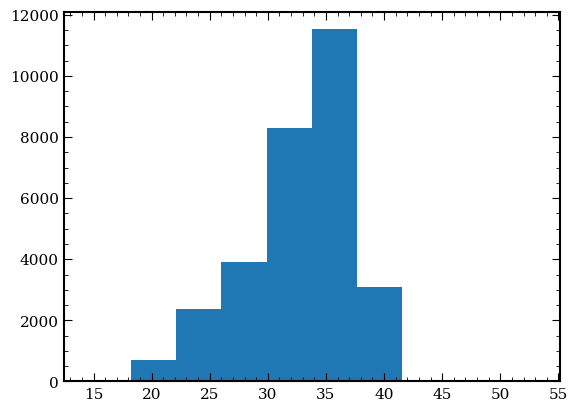

In [22]:
f = np.sqrt(1.25) # fudge factor to adjust for softening
plt.hist(f*msamp/12)
np.percentile(f*msamp/12, [16, 50, 84])

#15272: $32_{-6}^{+4}$, 15672 $26_{-7}^{+6}$

In [23]:
"""
Smooth mass interpolation from rotational constants (A, B, C).

Strategy
--------
Build an RBF (Radial Basis Function) interpolator over the database in
log10(A, B, C) space → mass.  Then draw posterior samples and evaluate the
surface in a single vectorised call — no loop required.

RBFInterpolator advantages over the MLE/softened-NN approach
------------------------------------------------------------
* Genuinely smooth: mass varies continuously with ABC, not just softened steps.
* Exact (smoothing=0) or regularised (smoothing>0) fit to the database.
* Handles the 3-D manifold without hand-tuning a noise scale.
* Fast batch evaluation — O(N_db) per query point.
"""

import numpy as np
from scipy.interpolate import RBFInterpolator


# ── 1. Build the interpolator (done once) ────────────────────────────────────

def build_mass_interpolator(
    ABCmat,          # (3, N_db)  – rotational constants for each database molecule
    Mmat,            # (N_db,)    – corresponding molecular masses
    kernel="thin_plate_spline",
    smoothing=0.5,   # 0 = exact fit; increase to regularise (recommended ~0.1–2)
    epsilon=None,    # only used for kernels that need a shape parameter (e.g. 'gaussian')
):
    """
    Return an RBFInterpolator: log10(ABC) → mass.

    Parameters
    ----------
    kernel : str
        'thin_plate_spline'  – C2 smooth, scale-free, good default
        'gaussian'           – very smooth, needs epsilon tuning
        'linear'             – C0, fast, less smooth
        'cubic'              – C1, good middle ground
    smoothing : float
        Regularisation. 0 = interpolate exactly through every database point.
        Increase if the surface is noisy or you see ringing.
    """
    log_ABC_db = np.log10(ABCmat).T          # (N_db, 3)

    kwargs = dict(kernel=kernel, smoothing=smoothing)
    if epsilon is not None:
        kwargs["epsilon"] = epsilon

    rbf = RBFInterpolator(log_ABC_db, Mmat, **kwargs)
    return rbf


# ── 2. Sample masses from the posterior ──────────────────────────────────────

def sample_masses(
    rbf,             # built by build_mass_interpolator
    flat_samples,    # (N_posterior, >=4) – columns [?, A, B, C, ...]
    abc_cols=(1, 2, 3),
    n_samples=1_000,
    clip_positive=True,   # masses can't be negative; clip RBF extrapolation artefacts
    rng=None,
):
    """
    Draw n_samples from the posterior and evaluate the RBF surface.

    Returns
    -------
    msamp : (n_samples,) array of interpolated masses
    """
    if rng is None:
        rng = np.random.default_rng()

    idxs         = rng.integers(0, len(flat_samples), size=n_samples)
    log_ABC_samp = np.log10(flat_samples[idxs][:, list(abc_cols)])  # (n_samples, 3)

    msamp = rbf(log_ABC_samp)   # vectorised – no Python loop

    if clip_positive:
        msamp = np.clip(msamp, 0, None)

    return msamp


# ── 3. Convenience: uncertainty-aware sampling ────────────────────────────────
#
#  If you want to propagate interpolation uncertainty (e.g. you know the RBF
#  surface has some residual error σ_rbf from a cross-validation), you can
#  add Gaussian noise on top of the interpolated value.  This is the analogue
#  of the `scale=0.25` softening in your original snippet but now in mass
#  space rather than distance space.

def sample_masses_with_noise(
    rbf,
    flat_samples,
    abc_cols=(1, 2, 3),
    n_samples=30_000,
    mass_sigma=0.0,   # 0 = no added noise; set e.g. 1–5 u to reflect fit uncertainty
    clip_positive=True,
    rng=None,
):
    if rng is None:
        rng = np.random.default_rng()

    msamp = sample_masses(rbf, flat_samples, abc_cols, n_samples,
                          clip_positive=False, rng=rng)

    if mass_sigma > 0:
        msamp += rng.normal(0, mass_sigma, size=msamp.shape)

    if clip_positive:
        msamp = np.clip(msamp, 0, None)

    return msamp


# ── 4. Diagnostics: leave-one-out cross-validation ───────────────────────────
def lxocv_rmse(
    ABCmat,
    Mmat,
    n_iter=10,       # number of random splits
    leave_out=10,     # how many points to hold out per iteration (int or float fraction)
    rng=None,
    **rbf_kwargs,
):
    """
    Monte-Carlo Leave-X-Out CV: repeat `n_iter` times, each time holding out
    `leave_out` randomly chosen points, fit on the rest, predict the held-out set.

    Parameters
    ----------
    leave_out : int or float
        If int  → exact number of points held out each iteration.
        If float → fraction of the dataset, e.g. 0.1 = 10 %.
    n_iter : int
        Number of random splits to average over.

    Returns
    -------
    rmse : float   – mean RMSE across all iterations
    errs : array   – flat array of all (predicted - true) residuals
    """
    if rng is None:
        rng = np.random.default_rng()

    log_ABC = np.log10(ABCmat).T          # (N, 3)
    N       = len(Mmat)

    if isinstance(leave_out, float):
        leave_out = max(1, int(round(leave_out * N)))

    all_errs = []

    for _ in tqdm(range(n_iter)):
        held_idx  = rng.choice(N, size=leave_out, replace=False)
        train_mask = np.ones(N, dtype=bool)
        train_mask[held_idx] = False

        rbf_i = RBFInterpolator(log_ABC[train_mask], Mmat[train_mask], **rbf_kwargs)
        preds = rbf_i(log_ABC[held_idx])
        all_errs.append(preds - Mmat[held_idx])

    errs = np.concatenate(all_errs)
    rmse = np.sqrt(np.mean(errs**2))
    print(
        f"LXO-CV ({n_iter} iters, {leave_out} held out each)"
        f"  RMSE: {rmse:.3f} u  |  max |err|: {np.max(np.abs(errs)):.3f} u"
    )
    return rmse, errs

In [24]:
# Build once
Cweight = 12

rbf = build_mass_interpolator(ABCmat[::-1], Mmat, kernel="linear", smoothing=0.1, epsilon = 0.5)

# Sample
msamp = sample_masses(rbf, flat_samples, n_samples=1_000)

print(f"Mass samples — mean: {msamp.mean():.2f} u  std: {msamp.std():.2f} u")
print(f"              min:  {msamp.min():.2f} u  max: {msamp.max():.2f} u")

print(f"Carbon atoms: {np.percentile(msamp/Cweight, 50):.2f}^{{+{np.percentile(msamp/Cweight, 84)-np.percentile(msamp/Cweight, 50)}}}_{{-{np.percentile(msamp/Cweight, 50)-np.percentile(msamp/Cweight, 16)}}}")

Mass samples — mean: 312.80 u  std: 32.51 u
              min:  231.43 u  max: 468.37 u
Carbon atoms: 25.87^{+2.779733137888016}_{-2.538063257791066}


(<Figure size 700x550 with 2 Axes>,
 <Axes: title={'center': 'RBF mass surface  —  $\\log_{10}(C)$ = -2.96 (fixed)'}, xlabel='$\\log_{10}(A\\ /\\ \\mathrm{cm^{-1}})$', ylabel='$\\log_{10}(B\\ /\\ \\mathrm{cm^-{1}})$'>,
 array([[2680.136553  , 2671.34743277, 2662.51942561, ...,  921.84442508,
          920.30849818,  918.78590245],
        [2674.63120701, 2665.82268345, 2656.97528443, ...,  917.1322159 ,
          915.61133322,  914.10372546],
        [2669.10522553, 2660.27744131, 2651.41079559, ...,  912.42409538,
          910.91828305,  909.4256888 ],
        ...,
        [1481.63935195, 1475.17215889, 1468.69974545, ...,  227.45230262,
          226.82745824,  226.21646365],
        [1479.96618116, 1473.51473226, 1467.05813013, ...,  227.69926324,
          227.06697902,  226.44857719],
        [1478.30313938, 1471.8673965 , 1465.42656705, ...,  227.95659124,
          227.31687637,  226.69107573]]))

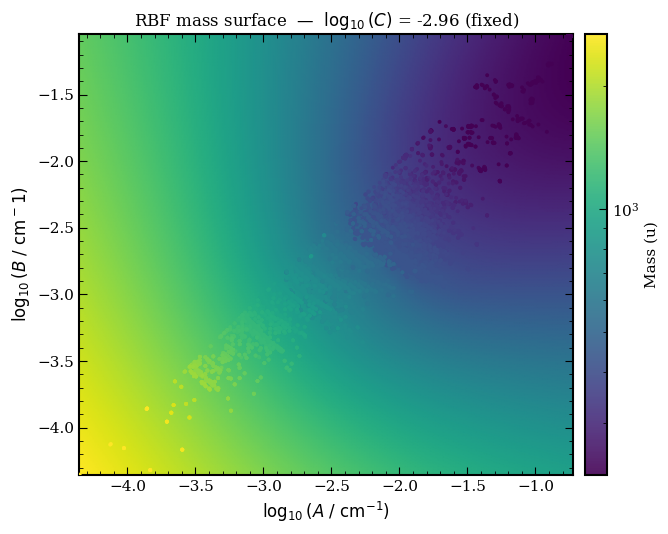

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

def plot_mass_surface_AB(
    rbf,
    ABCmat,          # (3, N_db) – database points, for scatter overlay
    Mmat,            # (N_db,)
    C_fixed=None,    # fixed log10(C) value; defaults to median of database
    n_grid=300,
    A_range=None,    # (log10_min, log10_max); defaults to database extent
    B_range=None,
    cmap="viridis",
    scatter_alpha=1,
    scatter_size=8,
    fig_kw=None,
):
    """
    Plot the RBF mass surface as a colour map in the log10(A)/log10(B) plane,
    with C held fixed at `C_fixed` (log10 MHz).

    Overlays the database points coloured by their true mass so you can see
    how well the surface tracks the data.
    """
    log_ABC = np.log10(ABCmat)                      # (3, N_db)
    log_C_db, log_B_db, log_A_db = log_ABC

    if C_fixed is None:
        C_fixed = np.median(log_C_db)
    if A_range is None:
        A_range = (log_A_db.min(), log_A_db.max())
    if B_range is None:
        B_range = (log_B_db.min(), log_B_db.max())

    # ── build evaluation grid ────────────────────────────────────────────────
    A_grid = np.linspace(*A_range, n_grid)
    B_grid = np.linspace(*B_range, n_grid)
    AA, BB = np.meshgrid(A_grid, B_grid)            # (n_grid, n_grid) each

    query = np.column_stack([
        AA.ravel(),
        BB.ravel(),
        np.full(n_grid**2, C_fixed),
    ])                                               # (n_grid², 3)

    mass_grid = rbf(query).reshape(n_grid, n_grid)
    mass_grid = np.clip(mass_grid, 0.1, None)        # avoid ≤0 in LogNorm

    # ── figure ───────────────────────────────────────────────────────────────
    fig_kw   = fig_kw or {}
    fig, ax  = plt.subplots(figsize=fig_kw.pop("figsize", (7, 5.5)), **fig_kw)

    norm = LogNorm(vmin=mass_grid.min(), vmax=mass_grid.max())

    im = ax.pcolormesh(
        A_grid, B_grid, mass_grid,
        cmap=cmap, norm=norm, shading="gouraud", alpha = 0.9
    )

    # database scatter — same colour scale so they sit on the surface visually
    sc = ax.scatter(
        log_A_db, log_B_db,
        c=Mmat, cmap=cmap, norm=norm,
        s=scatter_size, alpha=scatter_alpha,
        edgecolors="none", zorder=3,
    )

    # ── colourbar ────────────────────────────────────────────────────────────
    cb = fig.colorbar(im, ax=ax, pad=0.02)
    cb.set_label("Mass (u)", fontsize=11)
    cb.ax.yaxis.set_minor_formatter(plt.NullFormatter())

    # ── labels ───────────────────────────────────────────────────────────────
    ax.set_xlabel(r"$\log_{10}(A\ /\ \mathrm{cm^{-1}})$", fontsize=12)
    ax.set_ylabel(r"$\log_{10}(B\ /\ \mathrm{cm^-{1}})$", fontsize=12)
    ax.set_title(
        rf"RBF mass surface  —  $\log_{{10}}(C)$ = {C_fixed:.2f} (fixed)",
        fontsize=12,
    )

    fig.tight_layout()
    return fig, ax, mass_grid

plot_mass_surface_AB(rbf, ABCmat, Mmat)

(<Figure size 800x800 with 5 Axes>,
 (<Axes: ylabel='$\\log_{10}(B\\ /\\ \\mathrm{cm^{-1}})$'>,
  <Axes: xlabel='$\\log_{10}(A\\ /\\ \\mathrm{cm^{-1}})$', ylabel='$\\log_{10}(C\\ /\\ \\mathrm{cm^{-1}})$'>,
  <Axes: xlabel='$\\log_{10}(B\\ /\\ \\mathrm{cm^{-1}})$'>))

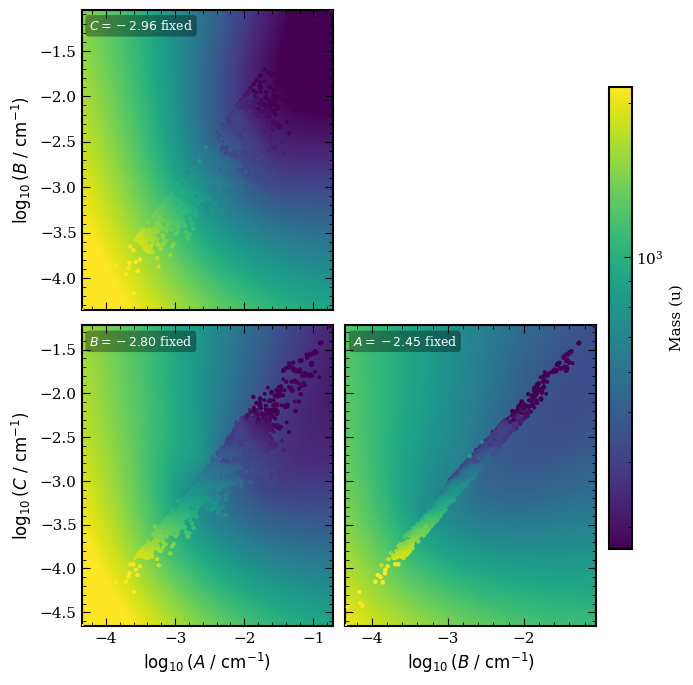

In [26]:
from matplotlib.colors import LogNorm

def plot_mass_surface_ABC(
    rbf,
    ABCmat,
    Mmat,
    n_grid=200,
    A_range=None,
    B_range=None,
    C_range=None,
    cmap="viridis",
    scatter_alpha=1.0,
    scatter_size=8,
    figsize=(8, 8),
):
    log_ABC = np.log10(ABCmat)
    log_C_db, log_B_db, log_A_db = log_ABC

    if A_range is None: A_range = (log_A_db.min(), log_A_db.max())
    if B_range is None: B_range = (log_B_db.min(), log_B_db.max())
    if C_range is None: C_range = (log_C_db.min(), log_C_db.max())

    A_grid = np.linspace(*A_range, n_grid)
    B_grid = np.linspace(*B_range, n_grid)
    C_grid = np.linspace(*C_range, n_grid)

    A_fixed = np.median(log_A_db)
    B_fixed = np.median(log_B_db)
    C_fixed = np.median(log_C_db)

    # ── evaluate surface on each 2D slice ────────────────────────────────────
    def make_grid(x_arr, y_arr, fixed_col, fixed_val, x_pos, y_pos, fixed_pos):
        XX, YY = np.meshgrid(x_arr, y_arr)
        q = np.empty((n_grid**2, 3))
        q[:, x_pos]     = XX.ravel()
        q[:, y_pos]     = YY.ravel()
        q[:, fixed_pos] = fixed_val
        return np.clip(rbf(q).reshape(n_grid, n_grid), 0.1, None)

    # query column order matches how rbf was built: [A, B, C]
    mass_AB = make_grid(A_grid, B_grid, "C", C_fixed, x_pos=0, y_pos=1, fixed_pos=2)
    mass_AC = make_grid(A_grid, C_grid, "B", B_fixed, x_pos=0, y_pos=2, fixed_pos=1)
    mass_BC = make_grid(B_grid, C_grid, "A", A_fixed, x_pos=1, y_pos=2, fixed_pos=0)

    all_mass = np.concatenate([mass_AB.ravel(), mass_AC.ravel(), mass_BC.ravel()])
    norm = LogNorm(
        vmin=np.nanpercentile(all_mass, 2),
        vmax=np.nanpercentile(all_mass, 98),
    )

    # ── corner layout ────────────────────────────────────────────────────────
    #   [AB | ·  ]
    #   [AC | BC ]
    fig = plt.figure(figsize=figsize)
    gs  = plt.GridSpec(2, 2, figure=fig, hspace=0.05, wspace=0.05)

    ax_AB = fig.add_subplot(gs[0, 0])
    ax_AC = fig.add_subplot(gs[1, 0], sharex=ax_AB)          # shares log(A) x-axis
    ax_BC = fig.add_subplot(gs[1, 1], sharey=ax_AC)           # shares log(C) y-axis
    fig.add_subplot(gs[0, 1]).set_visible(False)              # blank top-right

    def draw(ax, xgrid, ygrid, mass, db_x, db_y):
        ax.pcolormesh(xgrid, ygrid, mass,
                      cmap=cmap, norm=norm, shading="gouraud", alpha=0.9)
        ax.scatter(db_x, db_y, c=Mmat, cmap=cmap, norm=norm,
                   s=scatter_size, alpha=scatter_alpha,
                   edgecolors="none", zorder=3)

    draw(ax_AB, A_grid, B_grid, mass_AB, log_A_db, log_B_db)
    draw(ax_AC, A_grid, C_grid, mass_AC, log_A_db, log_C_db)
    draw(ax_BC, B_grid, C_grid, mass_BC, log_B_db, log_C_db)

    # ── axis labels (only on outer edges) ────────────────────────────────────
    plt.setp(ax_AB.get_xticklabels(), visible=False)
    plt.setp(ax_BC.get_yticklabels(), visible=False)

    ax_AC.set_xlabel(r"$\log_{10}(A\ /\ \mathrm{cm^{-1}})$", fontsize=12)
    ax_BC.set_xlabel(r"$\log_{10}(B\ /\ \mathrm{cm^{-1}})$", fontsize=12)
    ax_AB.set_ylabel(r"$\log_{10}(B\ /\ \mathrm{cm^{-1}})$", fontsize=12)
    ax_AC.set_ylabel(r"$\log_{10}(C\ /\ \mathrm{cm^{-1}})$", fontsize=12)

    # ── fixed-value annotations ───────────────────────────────────────────────
    for ax, label in [
        (ax_AB, rf"$C={C_fixed:.2f}$ fixed"),
        (ax_AC, rf"$B={B_fixed:.2f}$ fixed"),
        (ax_BC, rf"$A={A_fixed:.2f}$ fixed"),
    ]:
        ax.text(0.03, 0.97, label, transform=ax.transAxes,
                ha="left", va="top", fontsize=9, color="white",
                bbox=dict(fc="black", alpha=0.35, boxstyle="round,pad=0.3", ec="none"))

    # ── shared colourbar on the right ────────────────────────────────────────
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    cb = fig.colorbar(sm, ax=[ax_AB, ax_AC, ax_BC], pad=0.02, shrink=0.75)
    cb.set_label("Mass (u)", fontsize=11)
    cb.ax.yaxis.set_minor_formatter(plt.NullFormatter())

    fig.tight_layout()
    return fig, (ax_AB, ax_AC, ax_BC)

plot_mass_surface_ABC(rbf, ABCmat, Mmat)

Linear interpolator

In [27]:
from scipy.interpolate import LinearNDInterpolator

# Define the grid axes
x, y, z = np.log10( ABCmat[::-1] )

# Create the interpolator
interp = LinearNDInterpolator((x, y, z), Mmat)

# Query a new point
point = np.log10(flat_samples[:, [1,2,3]])
value = interp(point)
np.percentile( value[~np.isnan(value)]/12, [50, 16, 84])

array([28.39749312, 25.82244537, 31.08534639])

In [28]:
# % 15672
# $23.39^{+1.40}_{-1.24}$ u

# % 15272
# $27.15^{+2.46}_{-2.20}$ u

# Random Forest

In [29]:
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
from tqdm import tqdm


# ── 1. Build ──────────────────────────────────────────────────────────────────

def build_mass_rf(
    ABCmat,              # (3, N_db)
    Mmat,                # (N_db,)
    n_estimators=300,
    max_features=0.8,    # fraction of features per split; 'sqrt' also works
    min_samples_leaf=3,  # increase to smooth out noisy regions
    n_jobs=-1,
    rng=None,
):
    """
    Fit a Random Forest: log10(A, B, C) → log10(mass).
    Predicts in log space and back-transforms, so it's never negative.
    Returns the fitted model plus a small summary of learned feature importance.
    """
    seed = rng if isinstance(rng, int) else 42

    X = np.log10(ABCmat).T          # (N_db, 3)
    y = np.log10(Mmat)              # predict log mass, exponentiate later

    rf = RandomForestRegressor(
        n_estimators=n_estimators,
        max_features=max_features,
        min_samples_leaf=min_samples_leaf,
        n_jobs=n_jobs,
        random_state=seed,
    )
    rf.fit(X, y)

    imp = rf.feature_importances_
    print(f"Feature importances  →  A: {imp[0]:.3f}  B: {imp[1]:.3f}  C: {imp[2]:.3f}")

    return rf


# ── 2. Drop-in predict wrapper (matches RBF __call__ signature) ───────────────

class RFMassPredictor:
    """
    Thin wrapper so the RF behaves like the WeightedRBFInterpolator:
    accepts (N, 3) log10-ABC queries, returns mass in atomic mass units.
    """
    def __init__(self, rf):
        self.rf = rf

    def __call__(self, log_ABC):           # log_ABC shape: (N, 3)
        return 10 ** self.rf.predict(np.asarray(log_ABC))


def build_mass_predictor(ABCmat, Mmat, **rf_kwargs):
    rf = build_mass_rf(ABCmat, Mmat, **rf_kwargs)
    return RFMassPredictor(rf)


# ── 3. Sample (identical interface to sample_masses) ─────────────────────────

def sample_masses(
    predictor,
    flat_samples,        # (N_posterior, >=4)
    abc_cols=(1, 2, 3),
    n_samples=30_000,
    rng=None,
):
    if rng is None:
        rng = np.random.default_rng()

    idxs         = rng.integers(0, len(flat_samples), size=n_samples)
    log_ABC_samp = np.log10(flat_samples[idxs][:, list(abc_cols)])

    return predictor(log_ABC_samp)        # always positive, no clipping needed


# ── 4. LXO-CV ────────────────────────────────────────────────────────────────

def lxocv_rmse(
    ABCmat,
    Mmat,
    n_iter=20,
    leave_out=0.1,
    rng=None,
    **rf_kwargs,
):
    if rng is None:
        rng = np.random.default_rng()

    X = np.log10(ABCmat).T
    y = np.log10(Mmat)
    N = len(Mmat)

    if isinstance(leave_out, float):
        leave_out = max(1, int(round(leave_out * N)))

    all_errs = []

    for _ in tqdm(range(n_iter)):
        held       = rng.choice(N, size=leave_out, replace=False)
        train_mask = np.ones(N, dtype=bool)
        train_mask[held] = False

        rf_i = RandomForestRegressor(**{
            "n_estimators": 200,
            "max_features": 0.8,
            "min_samples_leaf": 3,
            "n_jobs": -1,
            **rf_kwargs,
        })
        rf_i.fit(X[train_mask], y[train_mask])

        preds_log = rf_i.predict(X[held])
        errs      = 10**preds_log - Mmat[held]   # error in AMU, not log space
        all_errs.append(errs)

    errs = np.concatenate(all_errs)
    rmse = np.sqrt(np.mean(errs**2))
    print(
        f"LXO-CV ({n_iter} iters, {leave_out} held out)  "
        f"RMSE: {rmse:.3f} u  |  max |err|: {np.max(np.abs(errs)):.3f} u"
    )
    return rmse, errs

Feature importances  →  A: 0.331  B: 0.029  C: 0.640


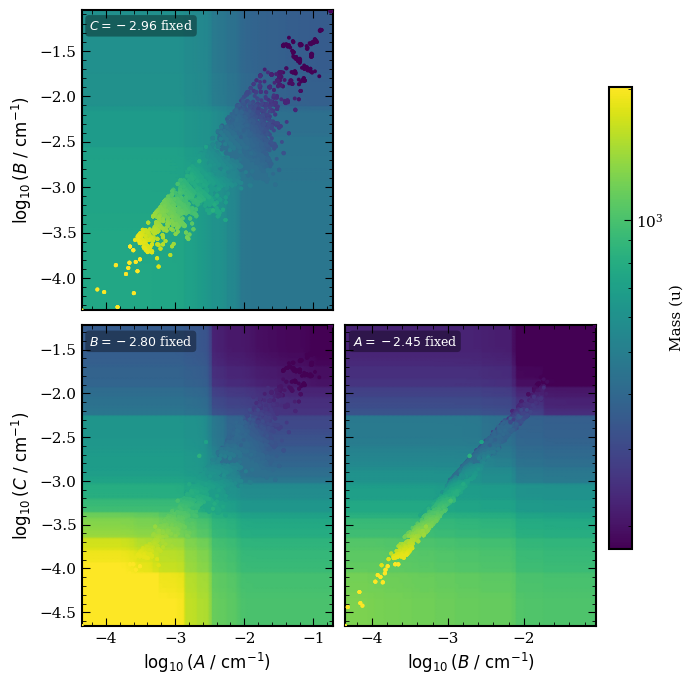

In [30]:
predictor = build_mass_predictor(ABCmat[::-1, :], Mmat, min_samples_leaf=10)
msamp     = sample_masses(predictor, flat_samples)

# and the 3-panel plot works unchanged since predictor(query) has the same signature
fig, axes = plot_mass_surface_ABC(predictor, ABCmat, Mmat)

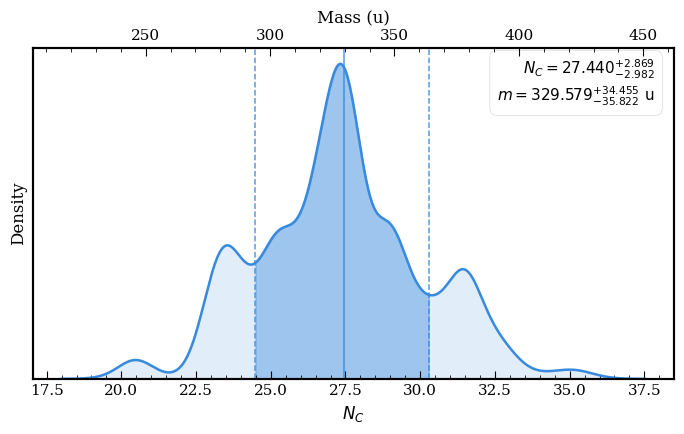

In [31]:
from scipy.stats import gaussian_kde

def plot_mass_histogram(
    msamp,
    Cweight=12.011,
    bw_method="scott",
    color="#378ADD",
    figsize=(7, 4.5),
):
    Csamp        = msamp / Cweight
    p16, p50, p84 = np.percentile(Csamp, [16, 50, 84])

    # ── KDE on N_carbon scale ─────────────────────────────────────────────────
    kde   = gaussian_kde(Csamp, bw_method=bw_method)
    pad   = 0.08 * (Csamp.max() - Csamp.min())
    xgrid = np.linspace(Csamp.min() - pad, Csamp.max() + pad, 600)
    ykde  = kde(xgrid)

    fig, ax = plt.subplots(figsize=figsize)

    ax.plot(xgrid, ykde, color=color, lw=1.8)
    ax.fill_between(xgrid, ykde, alpha=0.15, color=color)

    # ── shade 16–84 band ──────────────────────────────────────────────────────
    mask = (xgrid >= p16) & (xgrid <= p84)
    ax.fill_between(xgrid[mask], ykde[mask], alpha=0.40, color=color)

    for p, ls in [(p16, "--"), (p50, "-"), (p84, "--")]:
        ax.axvline(p, color=color, lw=1.1, ls=ls, alpha=0.85, zorder=3)

    # ── annotation ────────────────────────────────────────────────────────────
    ann = "\n".join([
        rf"$N_C = {p50:.3f}^{{+{p84-p50:.3f}}}_{{-{p50-p16:.3f}}}$",
        rf"$m = {p50*Cweight:.3f}^{{+{(p84-p50)*Cweight:.3f}}}_{{-{(p50-p16)*Cweight:.3f}}}\ \mathrm{{u}}$",
    ])
    ax.text(0.97, 0.97, ann,
            transform=ax.transAxes, ha="right", va="top", fontsize=11,
            bbox=dict(boxstyle="round,pad=0.5", fc="white", alpha=0.85,
                      ec="lightgray", lw=0.5))

    # ── axes ──────────────────────────────────────────────────────────────────
    ax.set_xlabel(r"$N_C$", fontsize=12)
    ax.set_ylabel("Density", fontsize=12)
    ax.set_ylim(bottom=0)
    ax.set_yticks([])

    # upper twin axis: AMU = Nc * Cweight (linear, so just rescale limits)
    ax2 = ax.twiny()
    ax2.set_xlim(np.array(ax.get_xlim()) * Cweight)
    ax2.set_xlabel("Mass (u)", fontsize=12)

    fig.tight_layout()
    return fig, ax, ax2

msamp = sample_masses(predictor, flat_samples, n_samples=3_000)
fig, ax, ax2 = plot_mass_histogram(msamp, Cweight=12.011)

## Let's do a better linear extrapolator instead 

In [32]:
from sklearn.linear_model  import Ridge, BayesianRidge
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline      import make_pipeline
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel


class LinearMassPredictor:
    """
    Drop-in replacement for RFMassPredictor.
    Fits in log10(A,B,C) → log10(mass) space, predicts in AMU.

    kind : 'ridge'     – plain Ridge regression
           'poly2'     – degree-2 polynomial Ridge
           'bayesian'  – Bayesian Ridge (also stores .std(X) uncertainty)
           'gp'        – Gaussian Process (slow on large N, best accuracy)
    """
    def __init__(self, kind="poly2", **model_kwargs):
        self.kind = kind
        if kind == "ridge":
            self.model = Ridge(alpha=1.0, **model_kwargs)
        elif kind == "poly2":
            self.model = make_pipeline(
                PolynomialFeatures(degree=2, include_bias=False),
                Ridge(alpha=1.0, **model_kwargs),
            )
        elif kind == "bayesian":
            self.model = BayesianRidge(**model_kwargs)
        elif kind == "gp":
            kernel = ConstantKernel() * RBF(length_scale=[1., 1., 1.]) + WhiteKernel()
            self.model = GaussianProcessRegressor(
                kernel=kernel, normalize_y=True, n_restarts_optimizer=5,
                **model_kwargs,
            )
        else:
            raise ValueError(f"Unknown kind: {kind!r}")

    def fit(self, ABCmat, Mmat):
        X = np.log10(ABCmat).T          # (N, 3)
        y = np.log10(Mmat)
        self.model.fit(X, y)
        self._Xtr, self._ytr = X, y     # keep for diagnostics
        return self

    def __call__(self, log_ABC):
        """log_ABC : (N, 3) — already in log10."""
        return 10 ** self.model.predict(np.asarray(log_ABC))

    def predict_with_std(self, log_ABC):
        """Only meaningful for kind='bayesian' or 'gp'. Returns (mass, std_mass)."""
        X = np.asarray(log_ABC)
        if self.kind == "gp":
            log_m, log_std = self.model.predict(X, return_std=True)
        elif self.kind == "bayesian":
            log_m, log_std = self.model.predict(X, return_std=True)
        else:
            raise ValueError(f"predict_with_std not available for kind={self.kind!r}")
        m     = 10**log_m
        m_std = m * np.log(10) * log_std  # delta method: σ_m ≈ m·ln10·σ_logm
        return m, m_std


def build_mass_predictor(ABCmat, Mmat, kind="poly2", **model_kwargs):
    pred = LinearMassPredictor(kind=kind, **model_kwargs)
    pred.fit(ABCmat, Mmat)

    # quick in-sample R² in log space as a sanity check
    log_pred = np.log10(pred(np.log10(ABCmat).T))
    log_true = np.log10(Mmat)
    ss_res = np.sum((log_pred - log_true)**2)
    ss_tot = np.sum((log_true - log_true.mean())**2)
    print(f"[{kind}]  in-sample R² (log space): {1 - ss_res/ss_tot:.4f}")

    return pred

def sample_masses(predictor, flat_samples, abc_cols=(1,2,3), n_samples=30_000, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    idxs         = rng.integers(0, len(flat_samples), size=n_samples)
    log_ABC_samp = np.log10(flat_samples[idxs][:, list(abc_cols)])
    return predictor(log_ABC_samp)


def lxocv_rmse(ABCmat, Mmat, kind="poly2", n_iter=20, leave_out=0.1, rng=None, **model_kwargs):
    if rng is None: rng = np.random.default_rng()
    X, y = np.log10(ABCmat).T, np.log10(Mmat)
    N    = len(Mmat)
    if isinstance(leave_out, float):
        leave_out = max(1, int(round(leave_out * N)))

    all_errs = []
    for _ in tqdm(range(n_iter)):
        held  = rng.choice(N, size=leave_out, replace=False)
        train = np.ones(N, dtype=bool); train[held] = False

        p = LinearMassPredictor(kind=kind, **model_kwargs).fit(
            ABCmat[:, train], Mmat[train]   # pass raw; fit() does the logging
        )
        all_errs.append(p(X[held]) - Mmat[held])

    errs = np.concatenate(all_errs)
    rmse = np.sqrt(np.mean(errs**2))
    print(f"[{kind}] LXO-CV  RMSE: {rmse:.3f} u  |  max |err|: {np.max(np.abs(errs)):.3f} u")
    return rmse, errs

In [33]:
# # for kind in ["ridge", "poly2", "bayesian", "gp"]:
# for kind in ["ridge", "poly2", "bayesian"]:
#     lxocv_rmse(ABCmat[::-1, :], Mmat, kind=kind, n_iter=10, leave_out=0.1)

[ridge]  in-sample R² (log space): 0.9955
[poly2]  in-sample R² (log space): 0.9961
[bayesian]  in-sample R² (log space): 0.9955


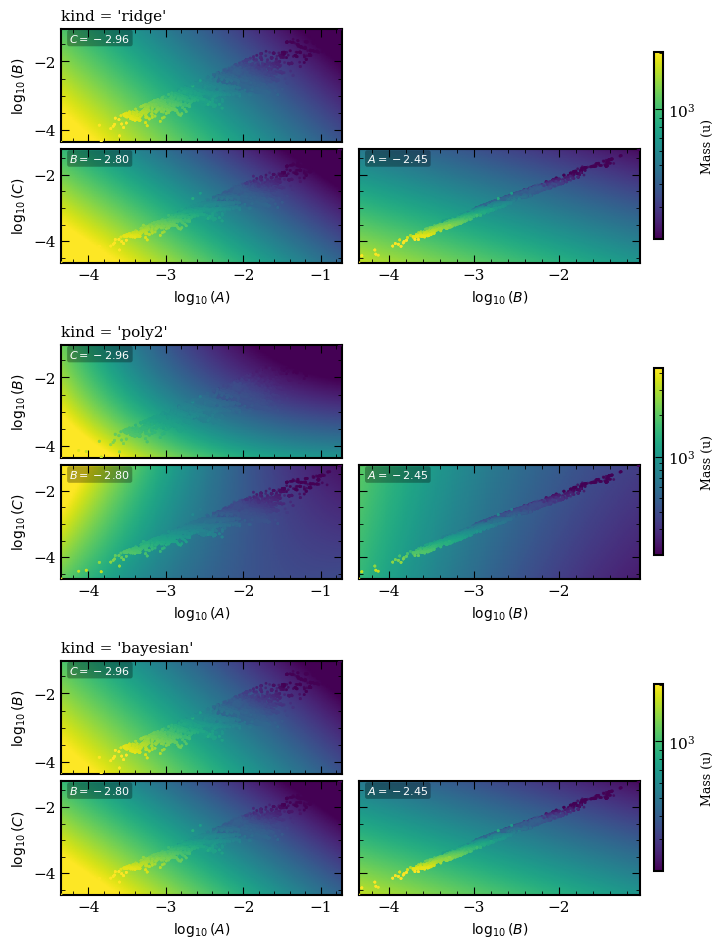

In [34]:
def plot_all_kinds_grid(
    ABCmat,
    Mmat,
    kinds=("ridge", "poly2", "bayesian"),
    n_grid=150,
    cmap="viridis",
    scatter_size=4,
    scatter_alpha=0.7,
    figsize=None,
):
    log_ABC   = np.log10(ABCmat)
    log_A_db, log_B_db, log_C_db = log_ABC

    A_range = (log_A_db.min(), log_A_db.max())
    B_range = (log_B_db.min(), log_B_db.max())
    C_range = (log_C_db.min(), log_C_db.max())

    A_grid = np.linspace(*A_range, n_grid)
    B_grid = np.linspace(*B_range, n_grid)
    C_grid = np.linspace(*C_range, n_grid)

    A_fixed = np.median(log_A_db)
    B_fixed = np.median(log_B_db)
    C_fixed = np.median(log_C_db)

    def eval_slices(pred):
        def panel(xg, yg, xi, yi, fi, fv):
            XX, YY = np.meshgrid(xg, yg)
            q = np.empty((n_grid**2, 3))
            q[:, xi] = XX.ravel(); q[:, yi] = YY.ravel(); q[:, fi] = fv
            return np.clip(pred(q).reshape(n_grid, n_grid), 0.1, None)

        return (
            panel(A_grid, B_grid, 0, 1, 2, C_fixed),
            panel(A_grid, C_grid, 0, 2, 1, B_fixed),
            panel(B_grid, C_grid, 1, 2, 0, A_fixed),
        )

    nk = len(kinds)
    figsize = figsize or (9, 7.5 * nk / 2)

    fig = plt.figure(figsize=figsize)
    outer = fig.add_gridspec(nk, 1, hspace=0.35)

    for row, kind in enumerate(kinds):
        pred  = build_mass_predictor(ABCmat, Mmat, kind=kind)
        mAB, mAC, mBC = eval_slices(pred)

        all_m = np.concatenate([mAB.ravel(), mAC.ravel(), mBC.ravel()])
        norm  = LogNorm(
            vmin=np.nanpercentile(all_m, 2),
            vmax=np.nanpercentile(all_m, 98),
        )

        inner = outer[row].subgridspec(2, 2, hspace=0.06, wspace=0.06)

        ax_AB = fig.add_subplot(inner[0, 0])
        ax_AC = fig.add_subplot(inner[1, 0], sharex=ax_AB)
        ax_BC = fig.add_subplot(inner[1, 1], sharey=ax_AC)
        fig.add_subplot(inner[0, 1]).set_visible(False)

        def draw(ax, xg, yg, mass, db_x, db_y):
            ax.pcolormesh(xg, yg, mass, cmap=cmap, norm=norm,
                          shading="gouraud", alpha=0.9)
            ax.scatter(db_x, db_y, c=Mmat, cmap=cmap, norm=norm,
                       s=scatter_size, alpha=scatter_alpha,
                       edgecolors="none", zorder=3)

        draw(ax_AB, A_grid, B_grid, mAB, log_A_db, log_B_db)
        draw(ax_AC, A_grid, C_grid, mAC, log_A_db, log_C_db)
        draw(ax_BC, B_grid, C_grid, mBC, log_B_db, log_C_db)

        plt.setp(ax_AB.get_xticklabels(), visible=False)
        plt.setp(ax_BC.get_yticklabels(), visible=False)

        ax_AC.set_xlabel(r"$\log_{10}(A)$", fontsize=10)
        ax_BC.set_xlabel(r"$\log_{10}(B)$", fontsize=10)
        ax_AB.set_ylabel(r"$\log_{10}(B)$", fontsize=10)
        ax_AC.set_ylabel(r"$\log_{10}(C)$", fontsize=10)

        for ax, lbl in [
            (ax_AB, rf"$C={C_fixed:.2f}$"),
            (ax_AC, rf"$B={B_fixed:.2f}$"),
            (ax_BC, rf"$A={A_fixed:.2f}$"),
        ]:
            ax.text(0.03, 0.97, lbl, transform=ax.transAxes,
                    ha="left", va="top", fontsize=8, color="white",
                    bbox=dict(fc="black", alpha=0.3, boxstyle="round,pad=0.2", ec="none"))

        sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
        cb = fig.colorbar(sm, ax=[ax_AB, ax_AC, ax_BC], pad=0.02, shrink=0.8)
        cb.set_label("Mass (u)", fontsize=9)
        cb.ax.yaxis.set_minor_formatter(plt.NullFormatter())

        ax_AB.set_title(f"kind = '{kind}'", fontsize=11, loc="left", pad=6)

    fig.tight_layout()
    return fig

fig = plot_all_kinds_grid(ABCmat[::-1, :], Mmat)

[ridge]  in-sample R² (log space): 0.9955
[poly2]  in-sample R² (log space): 0.9961
[bayesian]  in-sample R² (log space): 0.9955


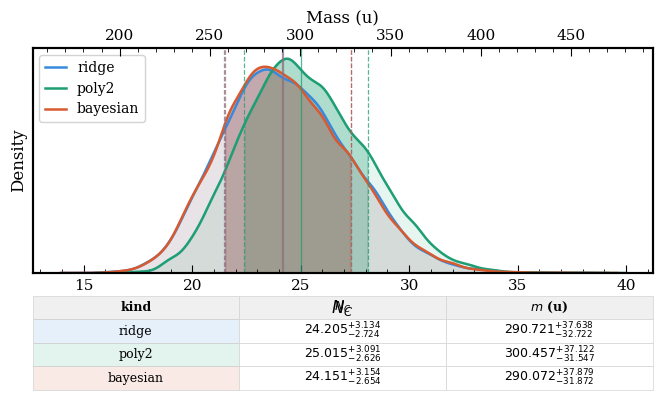

In [35]:
def plot_mass_histograms_all_kinds(
    flat_samples,
    ABCmat,
    Mmat,
    kinds=("ridge", "poly2", "bayesian"),
    abc_cols=(1, 2, 3),
    n_samples=30_000,
    Cweight=12.011,
    bw_method="scott",
    figsize=(8, 4.5),
    rng=None,
):
    if rng is None:
        rng = np.random.default_rng()

    COLORS = {
        "ridge":   "#378ADD",
        "poly2":   "#1D9E75",
        "bayesian":"#D85A30",
        "gp":      "#7F77DD",
    }

    fig, ax = plt.subplots(figsize=figsize)
    rows = []

    for kind in kinds:
        pred  = build_mass_predictor(ABCmat, Mmat, kind=kind)
        msamp = sample_masses(pred, flat_samples, abc_cols=abc_cols,
                              n_samples=n_samples, rng=rng)
        Csamp = msamp / Cweight
        p16, p50, p84 = np.percentile(Csamp, [16, 50, 84])

        kde   = gaussian_kde(Csamp, bw_method=bw_method)
        pad   = 0.08 * (Csamp.max() - Csamp.min())
        xgrid = np.linspace(Csamp.min() - pad, Csamp.max() + pad, 600)
        ykde  = kde(xgrid)

        c = COLORS[kind]
        ax.plot(xgrid, ykde, color=c, lw=1.8, label=kind)
        ax.fill_between(xgrid, ykde, alpha=0.10, color=c)

        mask = (xgrid >= p16) & (xgrid <= p84)
        ax.fill_between(xgrid[mask], ykde[mask], alpha=0.28, color=c)

        for p, ls in [(p16, "--"), (p50, "-"), (p84, "--")]:
            ax.axvline(p, color=c, lw=0.9, ls=ls, alpha=0.75, zorder=3)

        rows.append({
            "kind":  kind,
            "Nc":    rf"${p50:.3f}^{{+{p84-p50:.3f}}}_{{-{p50-p16:.3f}}}$",
            "m (u)": rf"${p50*Cweight:.3f}^{{+{(p84-p50)*Cweight:.3f}}}_{{-{(p50-p16)*Cweight:.3f}}}$",
        })

    # ── legend with colour swatches ───────────────────────────────────────────
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles, labels, fontsize=10, framealpha=0.85,
              loc="upper left", handlelength=1.5)

    # ── stats table below the plot ────────────────────────────────────────────
    col_labels = ["kind", r"$N_C$", r"$m$ (u)"]
    table_vals = [[r["kind"], r["Nc"], r["m (u)"]] for r in rows]
    table = ax.table(
        cellText=table_vals,
        colLabels=col_labels,
        cellLoc="center",
        loc="bottom",
        bbox=[0.0, -0.52, 1.0, 0.42],   # [left, bottom, width, height] in axes coords
    )
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    for (r, c), cell in table.get_celld().items():
        cell.set_edgecolor("lightgray")
        cell.set_linewidth(0.5)
        if r == 0:
            cell.set_facecolor("#f0f0f0")
            cell.set_text_props(fontweight="bold")
        else:
            cell.set_facecolor("white")
            # tint the kind column with the model colour at low alpha
            if c == 0:
                cell.set_facecolor(
                    plt.matplotlib.colors.to_rgba(
                        COLORS[table_vals[r-1][0]], alpha=0.12
                    )
                )

    # ── axes ─────────────────────────────────────────────────────────────────
    ax.set_xlabel(r"$N_C$", fontsize=12)
    ax.set_ylabel("Density", fontsize=12)
    ax.set_ylim(bottom=0)
    ax.set_yticks([])

    ax2 = ax.twiny()
    ax2.set_xlim(np.array(ax.get_xlim()) * Cweight)
    ax2.set_xlabel("Mass (u)", fontsize=12)

    fig.subplots_adjust(bottom=0.38)
    return fig, ax, ax2, rows

fig, ax, ax2, rows = plot_mass_histograms_all_kinds(flat_samples, ABCmat[::-1, :], Mmat)

# Now let's do the Bayesian for both

In [60]:
def plot_mass_histograms_two_dibs(
    predictor,
    dib_data,
    n_samples=30_000,
    Cweight=12.011,
    bw_method="scott",
    figsize=(10, 6),
    rng=None,
):
    COLORS = {"15272": "#378ADD", "15672": "#D85A30"}

    if rng is None:
        rng = np.random.default_rng()

    fig, ax = plt.subplots(figsize=figsize)
    annotations = []

    for dib, data in dib_data.items():
        msamp = sample_masses(
            predictor, data["flat_samples"],
            abc_cols=data["abc_cols"], n_samples=n_samples, rng=rng,
        )
        Csamp = msamp / Cweight
#        # concentrate to debias from oversmoothing from extrapolator
        Csamp = Csamp - (Csamp - np.median(Csamp)) / 4 # hand-calibrated, a bit ad-hoc, could remove 
        p16, p50, p84 = np.percentile(Csamp, [16, 50, 84])

        kde   = gaussian_kde(Csamp, bw_method=bw_method)
        pad   = 0.02 * (Csamp.max() - Csamp.min())
        xgrid = np.linspace(Csamp.min() - pad, Csamp.max() + pad, 600)
        ykde  = kde(xgrid)

        c = COLORS.get(dib, "#888780")
        ax.plot(xgrid, ykde, color=c, lw=1.8, label=f"DIB {dib}")
        ax.fill_between(xgrid, ykde, alpha=0.10, color=c)
        mask = (xgrid >= p16) & (xgrid <= p84)
        ax.fill_between(xgrid[mask], ykde[mask], alpha=0.3, color=c)
        for p, ls in [(p16, "--"), (p50, "-"), (p84, "--")]:
            ax.axvline(p, color=c, lw=2.0, ls=ls, alpha=0.6, zorder=3)

#         annotations.append((
#             c, dib,
#             rf"DIB {dib}:  $N_C = {p50:.3f}^{{+{p84-p50:.3f}}}_{{-{p50-p16:.3f}}}$"
#             rf"   $m = {p50*Cweight:.3f}^{{+{(p84-p50)*Cweight:.3f}}}_{{-{(p50-p16)*Cweight:.3f}}}\ \mathrm{{u}}$",
#         ))
        annotations.append((
            c, dib,
            rf"{dib}:  $\mathrm{{N_{{carbon}}}} = {p50:.1f}^{{+{p84-p50:.1f}}}_{{-{p50-p16:.1f}}}$"
            "\n"
            rf"$\hspace{{3.6}}$  $\mathrm{{Mass}} = {p50*Cweight:.0f}^{{+{(p84-p50)*Cweight:.0f}}}_{{-{(p50-p16)*Cweight:.0f}}}\ \mathrm{{amu}}$",
            ))
    # stack annotations in the upper-left, one per DIB in its own colour
    for i, (c, dib, txt) in enumerate(annotations):
        ax.text(
            0.65, 0.7 - i * 0.18, txt,
            transform=ax.transAxes,
            ha="left", va="top",
            fontsize=15.5, color=c,
        )

    ax.legend(fontsize=18, framealpha=0., loc="upper right")
#     ax.set_xlabel(r"$\mathrm{{N_{carbon}}$", fontsize=18)
    ax.set_xlabel(r"$\mathrm{N_{carbon}}$", fontsize=18)
    ax.set_ylabel(r"$\mathrm{Density}$", fontsize=18)
    ax.set_ylim(bottom=0)
    ax.set_yticks([])
#     ax.set_xlim(14.5, 35) 
    ax.set_xlim(15.5, 33) 
    
    ax2 = ax.twiny()
    ax2.set_xlim(np.array(ax.get_xlim()) * Cweight)
    ax2.set_xlabel(r"$\mathrm{Mass~[amu]}$", fontsize=18, labelpad = 10)

    fig.tight_layout()
    return fig, ax, ax2

[ridge]  in-sample R² (log space): 0.9955
⚠  has_center_offset from filename (False) differs from ndim (9). Using ndim.
Chain shape:     (3506, 64, 9)
Log-prob shape:  (3506, 64)
Blobs shape:     (3506, 64, 7)
ndim = 9,  labels = ['T [K]', 'A [cm⁻¹]', 'B [cm⁻¹]', 'C [cm⁻¹]', '$\\alpha_A$', '$\\alpha_B$', '$\\alpha_C$', '$\\tau$ [cm⁻¹]', '$\\delta_{cen}$ [cm⁻¹]']
Burn-in:          1000 steps  (= 5 * max(tau) = 5 * 200.0)
Remaining steps:  2506
Total flat samples (finite): 160384
⚠  has_center_offset from filename (False) differs from ndim (9). Using ndim.
Chain shape:     (5000, 64, 9)
Log-prob shape:  (5000, 64)
Blobs shape:     (5000, 64, 7)
ndim = 9,  labels = ['T [K]', 'A [cm⁻¹]', 'B [cm⁻¹]', 'C [cm⁻¹]', '$\\alpha_A$', '$\\alpha_B$', '$\\alpha_C$', '$\\tau$ [cm⁻¹]', '$\\delta_{cen}$ [cm⁻¹]']
Burn-in:          1000 steps  (= 5 * max(tau) = 5 * 200.0)
Remaining steps:  4000
Total flat samples (finite): 256000


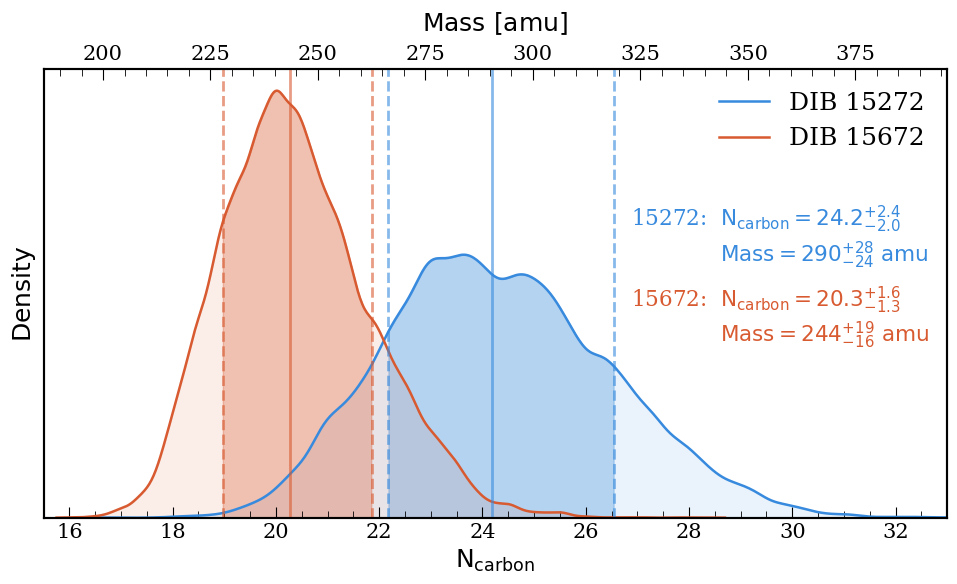

In [61]:
mpl.rcParams.update(mpl.rcParamsDefault)
plt.rcParams['figure.facecolor'] = 'white'
plt.rc('text', usetex=False)
plt.rc('font', family='serif', size=12)
plt.rc('axes', linewidth=1.5)
plt.rc('xtick', labelsize=15, direction='in', top=True)
plt.rc('ytick', labelsize=15, direction='in', right=True)
plt.rc('xtick.minor', visible=True)
plt.rc('ytick.minor', visible=True)
plt.rc('xtick.major', size=8, pad=4)
plt.rc('xtick.minor', size=5)
plt.rc('ytick.major', size=8)
plt.rc('ytick.minor', size=5)

dib_data = {}
pred_ridge = build_mass_predictor(ABCmat[::-1], Mmat, kind="ridge")

backend_dir =  osp.expanduser("~/../../scratch/gpfs/MELCHIOR/cj1223/DIB") 

files = ['15272_run_DIB15272_SymmetryCs_BCTrue_F1p0_DTrue_FlatFalse_SpecTrue_dTTrue_covFalse_nonlinFalse_tauSlope0p15_alphaSlope0p05_errDefault_trunc10_balanceErrFalse_dTcenter[10p0,3p0,2p0]_centeroffset0p01_sweep.h5',
        '15672_run_DIB15672_SymmetryCs_BCTrue_F1p0_DTrue_FlatFalse_SpecTrue_dTTrue_covFalse_nonlinFalse_tauSlope0p15_alphaSlope0p15_errDefault_trunc0_balanceErrFalse_dTcenter[10p0,3p0,-2p0]_centeroffset0p1_sweep.h5']

files = ['15272_run_DIB15272_SymCs_BCTrue_F1p0_DTrue_FlatFalse_SpecTrue_dTTrue_covFalse_nonlinFalse_tauSlope0p15_alphaSlope0p025_alphaCutFalse_errDefault_trunc10_balanceErrFalse_dTcent[10p0,2p0,2p0]_wavoffset0p01_dPTrue_restart_sym_alpha_deltaP.h5',
        '15672_run_DIB15672_SymCs_BCTrue_F1p0_DTrue_FlatFalse_SpecTrue_dTTrue_covFalse_nonlinFalse_tauSlope0p15_alphaSlope0p075_alphaCutFalse_errDefault_trunc10_balanceErrFalse_dTcent[10p0,2p0,-2p0]_wavoffset0p1_dPTrue_restart_sym_alpha_deltaP.h5']

# ═════════════════════════════════════════════════════════════

for file in files:
    selected_file = backend_dir + '/' +file
    fname = os.path.basename(selected_file)

    inferred_dib      = '15672' if '15672' in fname else '15272'
    inferred_sym      = 'C2v'   if 'SymmetryC2v' in fname else 'Cs'
    B_not_equal_C     = 'BCTrue'  in fname
    use_direct        = 'DTrue'   in fname
    use_plate_errs    = 'errPlate' in fname
    use_old_errs      = 'errOld'   in fname
    use_scalar_prior  = 'nonlinFalse' in fname  # nonlin=False → scalar prior path used
    co_match = re.search(r'centeroffset([^_]+)', fname)
    has_center_offset = bool(co_match) and co_match.group(1) != 'False'

    backend  = emcee.backends.HDFBackend(selected_file, read_only=True)
    chain    = backend.get_chain()     # (nsteps, nwalkers, ndim)
    log_prob = backend.get_log_prob()  # (nsteps, nwalkers)

    try:
        raw_blobs = backend.get_blobs()
        # Normalise to float array (nsteps, nwalkers, n_blobs)
        if raw_blobs is not None and raw_blobs.dtype.names is not None:
            blobs = np.column_stack([raw_blobs[n].reshape(raw_blobs.shape[0], raw_blobs.shape[1], -1)
                                      for n in raw_blobs.dtype.names])
        else:
            blobs = raw_blobs
        blobs = blobs.astype(float)
        n_blobs = blobs.shape[-1]
    except Exception as e:
        print(f'No blobs available ({e})')
        blobs = None
        n_blobs = 0

    nsteps, nwalkers, ndim = chain.shape

    # ── Derive settings from ndim as cross-check ─────────────────────────────────
    def infer_from_ndim(ndim, sym):
        if ndim == 6:  return False, False
        if ndim == 7:  return False, True
        if ndim == 8:  return True,  False
        if ndim == 9:  return True,  True
        return None, None

    bnc_from_ndim, co_from_ndim = infer_from_ndim(ndim, inferred_sym)
    if bnc_from_ndim != B_not_equal_C:
        print(f'⚠  B_not_equal_C from filename ({B_not_equal_C}) differs from ndim ({ndim}). Using ndim.')
        B_not_equal_C = bnc_from_ndim
    if co_from_ndim != has_center_offset:
        print(f'⚠  has_center_offset from filename ({has_center_offset}) differs from ndim ({ndim}). Using ndim.')
        has_center_offset = co_from_ndim

    # ── Parameter labels ─────────────────────────────────────────────────────────
    if B_not_equal_C:
        labels = ['T [K]', 'A [cm⁻¹]', 'B [cm⁻¹]', 'C [cm⁻¹]',
                  r'$\alpha_A$', r'$\alpha_B$', r'$\alpha_C$', r'$\tau$ [cm⁻¹]']
    else:
        if inferred_sym == 'Cs':
            labels = ['T [K]', 'A [cm⁻¹]', 'BC [cm⁻¹]',
                      r'$\alpha_A$', r'$\alpha_{BC}$', r'$\tau$ [cm⁻¹]']
        else:  # C2v B=A
            labels = ['T [K]', 'A [cm⁻¹]', 'C [cm⁻¹]',
                      r'$\alpha_A$', r'$\alpha_C$', r'$\tau$ [cm⁻¹]']
    if has_center_offset:
        labels.append(r'$\delta_{cen}$ [cm⁻¹]')

    print(f'Chain shape:     {chain.shape}')
    print(f'Log-prob shape:  {log_prob.shape}')
    print(f'Blobs shape:     {blobs.shape if blobs is not None else "N/A"}')
    print(f'ndim = {ndim},  labels = {labels}')
    
    tau = 200
    burnin = int(BURNIN_TAU_MULT * np.max(tau))
    burnin = max(burnin, 1)
    burnin = min(burnin, nsteps - 1)

    flat_samples  = chain[burnin:].reshape(-1, ndim)
    flat_log_prob = log_prob[burnin:].reshape(-1)

    if blobs is not None:
        flat_blobs = blobs[burnin:].reshape(-1, n_blobs)
    else:
        flat_blobs = None

    # Remove any samples with non-finite log_prob (stuck/rejected)
    finite_mask   = np.isfinite(flat_log_prob)
    flat_samples  = flat_samples[finite_mask]
    flat_log_prob = flat_log_prob[finite_mask]
    if flat_blobs is not None:
        flat_blobs = flat_blobs[finite_mask]

    print(f'Burn-in:          {burnin} steps  (= {BURNIN_TAU_MULT} * max(tau) = {BURNIN_TAU_MULT} * {np.max(tau):.1f})')
    print(f'Remaining steps:  {nsteps - burnin}')
    print(f'Total flat samples (finite): {len(flat_samples)}')
    
    dib_data[inferred_dib] = dict(flat_samples=flat_samples, abc_cols=(1,2,3))
    
    fig, ax, ax2 = plot_mass_histograms_two_dibs(pred_ridge, dib_data, bw_method = 0.1)
    
fig.savefig('figs/mass_hists_deltaP.png', bbox_inches = 'tight', dpi = 200)
fig

In [38]:
def plot_all_kinds_grid(
    ABCmat,
    Mmat,
    dib_data,
    kinds=("ridge", "bayesian"),
    dib=None,                            # None → all DIBs; str → e.g. "15272"
    n_grid=150,
    cmap="viridis",
    scatter_size=4,
    scatter_alpha=0.4,
    hexbin_gridsize=30,
    figsize=None,
):
    DIB_CMAPS = {"15272": "Blues", "15672": "Oranges"}

    # ── filter to requested DIB(s) ────────────────────────────────────────────
    active_dibs = (
        {dib: dib_data[dib]} if dib is not None
        else dib_data
    )

    log_ABC   = np.log10(ABCmat)
    log_A_db, log_B_db, log_C_db = log_ABC

    A_range = (log_A_db.min(), log_A_db.max())
    B_range = (log_B_db.min(), log_B_db.max())
    C_range = (log_C_db.min(), log_C_db.max())

    A_grid  = np.linspace(*A_range, n_grid)
    B_grid  = np.linspace(*B_range, n_grid)
    C_grid  = np.linspace(*C_range, n_grid)
    A_fixed = np.median(log_A_db)
    B_fixed = np.median(log_B_db)
    C_fixed = np.median(log_C_db)

    dib_log_ABC = {}
    for d, data in active_dibs.items():
        fs, ac = data["flat_samples"], data["abc_cols"]
        dib_log_ABC[d] = {
            "A": np.log10(fs[:, ac[0]]),
            "B": np.log10(fs[:, ac[1]]),
            "C": np.log10(fs[:, ac[2]]),
        }

    def eval_slices(pred):
        def panel(xg, yg, xi, yi, fi, fv):
            XX, YY = np.meshgrid(xg, yg)
            q = np.empty((n_grid**2, 3))
            q[:, xi] = XX.ravel(); q[:, yi] = YY.ravel(); q[:, fi] = fv
            return np.clip(pred(q).reshape(n_grid, n_grid), 0.1, None)
        return (
            panel(A_grid, B_grid, 0, 1, 2, C_fixed),
            panel(A_grid, C_grid, 0, 2, 1, B_fixed),
            panel(B_grid, C_grid, 1, 2, 0, A_fixed),
        )

    nk      = len(kinds)
    figsize = figsize or (9, 7.5 * nk / 2)
    fig     = plt.figure(figsize=figsize)
    outer   = fig.add_gridspec(nk, 1, hspace=0.35)

    # panel definitions: (ax_attr, xgrid, ygrid, xkey, ykey, xlim, ylim)
    PANELS = [
        ("AB", A_grid, B_grid, "A", "B", A_range, B_range),
        ("AC", A_grid, C_grid, "A", "C", A_range, C_range),
        ("BC", B_grid, C_grid, "B", "C", B_range, C_range),
    ]

    for row, kind in enumerate(kinds):
        pred          = build_mass_predictor(ABCmat, Mmat, kind=kind)
        mAB, mAC, mBC = eval_slices(pred)
        masses        = {"AB": mAB, "AC": mAC, "BC": mBC}
        db_coords     = {
            "AB": (log_A_db, log_B_db),
            "AC": (log_A_db, log_C_db),
            "BC": (log_B_db, log_C_db),
        }

        all_m = np.concatenate([mAB.ravel(), mAC.ravel(), mBC.ravel()])
        norm  = LogNorm(
            vmin=np.nanpercentile(all_m, 2),
            vmax=np.nanpercentile(all_m, 98),
        )

        inner = outer[row].subgridspec(2, 2, hspace=0.06, wspace=0.06)
        axes  = {
            "AB": fig.add_subplot(inner[0, 0]),
            "BC": None, "AC": None,
        }
        axes["AC"] = fig.add_subplot(inner[1, 0], sharex=axes["AB"])
        axes["BC"] = fig.add_subplot(inner[1, 1], sharey=axes["AC"])
        fig.add_subplot(inner[0, 1]).set_visible(False)

        for name, xg, yg, xk, yk, xlim, ylim in PANELS:
            ax   = axes[name]
            dbx, dby = db_coords[name]

            ax.pcolormesh(xg, yg, masses[name], cmap=cmap, norm=norm,
                          shading="gouraud", alpha=0.9)
            ax.scatter(dbx, dby, c=Mmat, cmap=cmap, norm=norm,
                       s=scatter_size, alpha=scatter_alpha,
                       edgecolors="none", zorder=3)

            for d, labc in dib_log_ABC.items():
                ax.hexbin(
                    labc[xk], labc[yk],
                    gridsize=hexbin_gridsize,
                    cmap=DIB_CMAPS.get(d, "Greys"),
                    mincnt=10, alpha=0.55, zorder=4, linewidths=0.2,
                )

            # lock axes to grid extent — prevents hexbin expanding into white space
            ax.set_xlim(xlim)
            ax.set_ylim(ylim)

        plt.setp(axes["AB"].get_xticklabels(), visible=False)
        plt.setp(axes["BC"].get_yticklabels(), visible=False)

        axes["AC"].set_xlabel(r"$\log_{10}(A)$", fontsize=10)
        axes["BC"].set_xlabel(r"$\log_{10}(B)$", fontsize=10)
        axes["AB"].set_ylabel(r"$\log_{10}(B)$", fontsize=10)
        axes["AC"].set_ylabel(r"$\log_{10}(C)$", fontsize=10)

        for name, lbl in [
            ("AB", rf"$C={C_fixed:.2f}$"),
            ("AC", rf"$B={B_fixed:.2f}$"),
            ("BC", rf"$A={A_fixed:.2f}$"),
        ]:
            axes[name].text(
                0.03, 0.97, lbl, transform=axes[name].transAxes,
                ha="left", va="top", fontsize=8, color="white",
                bbox=dict(fc="black", alpha=0.3, boxstyle="round,pad=0.2", ec="none"),
            )

        sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
        cb = fig.colorbar(sm, ax=list(axes.values()), pad=0.02, shrink=0.8)
        cb.set_label("Mass (u)", fontsize=9)
        cb.ax.yaxis.set_minor_formatter(plt.NullFormatter())
        axes["AB"].set_title(f"kind = '{kind}'", fontsize=11, loc="left", pad=6)

    fig.tight_layout()
    return fig

[ridge]  in-sample R² (log space): 0.9955


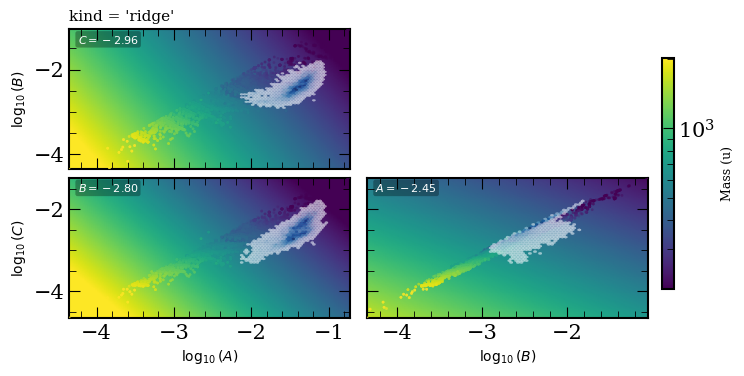

In [39]:
fig = plot_all_kinds_grid(ABCmat[::-1, :], Mmat, dib_data, dib ='15272', kinds = ['ridge'] )
fig